In [19]:
import requests
import pandas as pd
import re
import time
from bs4 import BeautifulSoup     
import matplotlib.pyplot as plt
import unicodedata
import os
from tqdm import tqdm
import ast

# Website Scraping

In [200]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urljoin

#url = "https://www.fda.gov/drugs/novel-drug-approvals-fda/novel-drug-approvals-2021"
ulr_2015_2020 = "https://web.archive.org/web/20240428045412/https://www.fda.gov/drugs/novel-drug-approvals-fda/novel-drug-approvals-{}"
ulr_2021_2024 = "https://www.fda.gov/drugs/novel-drug-approvals-fda/novel-drug-approvals-{}"

def extract_table_df(soup, base_url):
    """
    Find the approvals table and build a clean DataFrame.
    - Detects header rows even when <thead> is missing (common in older FDA pages / archives).
    - Skips the header row if it appears in <tbody>.
    - Normalizes column names across years.
    """
    from urllib.parse import urljoin

    # Try known containers
    container_selectors = [
        "#main-content > div > div.table-responsive",
        "#DataTables_Table_0_wrapper",
        "#main-content",
    ]
    container = None
    for sel in container_selectors:
        container = soup.select_one(sel)
        if container:
            break
    if not container:
        raise RuntimeError("Could not find any known table container.")

    # Find a table
    table = container.find("table")
    if not table:
        tables = container.find_all("table")
        if not tables:
            raise RuntimeError("Could not find a <table> inside the detected container.")
        table = tables[0]

    # Helper to normalize text
    def norm(s):
        return " ".join(s.strip().lower().replace("\xa0", " ").split())

    # Known header variants
    expected_headers = [
        ["no.", "drug name", "active ingredient", "approval date", "fda-approved use on approval date*"],
        ["no.", "drug name", "active ingredient", "date", "fda-approved use on approval date*"],
        ["no.", "drug name", "active ingredient", "approval date", "fda-approved use on approval date"],
        ["no.", "drug name", "active ingredient", "date", "fda-approved use on approval date"],
    ]

    # Try <thead> first
    thead_ths = table.select("thead th")
    if thead_ths:
        headers = [th.get_text(" ", strip=True) for th in thead_ths]
        skip_first_body_row = False
    else:
        # No thead: peek first tbody row; if it looks like headers, use it as headers and skip it
        first_tr = table.select_one("tbody tr")
        if not first_tr:
            raise RuntimeError("Table has no header and no body rows.")
        first_cells = [td.get_text(" ", strip=True) for td in first_tr.find_all(["td", "th"])]
        first_norm = [norm(x) for x in first_cells]
        if first_norm in expected_headers:
            headers = first_cells
            skip_first_body_row = True
        else:
            # Fallback: generic headers
            n_cols = len(first_cells)
            headers = [f"col_{i+1}" for i in range(n_cols)]
            skip_first_body_row = False

    # Collect rows + drug links
    rows, drug_links = [], []
    body_rows = table.select("tbody tr")
    if skip_first_body_row and body_rows:
        body_rows = body_rows[1:]  # drop header-like row from data

    for tr in body_rows:
        cells = tr.find_all(["td", "th"])
        if not cells:
            continue
        row_texts = [td.get_text(" ", strip=True) for td in cells]
        # normalize length to headers
        if len(row_texts) < len(headers):
            row_texts += [None] * (len(headers) - len(row_texts))
        elif len(row_texts) > len(headers):
            row_texts = row_texts[:len(headers)]
        rows.append(row_texts)

        # Drug URL typically in 2nd column ("Drug Name")
        a = cells[1].find("a") if len(cells) > 1 else None
        drug_links.append(urljoin(base_url, a["href"]) if a and a.get("href") else None)

    # Build DataFrame
    import pandas as pd
    df = pd.DataFrame(rows, columns=headers)

    # If we still ended up with generic col_1.. but the first data row looks like headers, fix that
    if df.columns[0].startswith("col_"):
        first_norm = [norm(x) for x in df.iloc[0].tolist()]
        if first_norm in expected_headers:
            df.columns = df.iloc[0].tolist()
            df = df.iloc[1:].reset_index(drop=True)

    # Normalize column names across years
    rename_map_candidates = {
        "No.": "no",
        "Drug Name": "drug_name",
        "Active Ingredient": "active_ingredient",
        "Approval Date": "approval_date",
        "Date": "approval_date",
        "FDA-approved use on approval date*": "fda_use_on_approval",
        "FDA-approved use on approval date": "fda_use_on_approval",
        "Drug URL": "drug_url",
    }
    df = df.rename(columns={k: v for k, v in rename_map_candidates.items() if k in df.columns})

    # Attach links
    if len(drug_links) == len(df):
        df["drug_url"] = drug_links

    # Clean up "no"
    if "no" in df.columns:
        df["no"] = (
            df["no"].astype(str).str.strip().str.rstrip(".").replace({"": None})
        )
        # Optional numeric:
        # df["no"] = pd.to_numeric(df["no"], errors="coerce").astype("Int64")

    # Coerce approval_date if present
    if "approval_date" in df.columns:
        df["approval_date"] = pd.to_datetime(df["approval_date"], errors="coerce")

    return df, sel


In [201]:
df_years = []

for year in range(2015, 2025):  # 2015..2023; change to 2025 if you want the latest included
    print(f"\nFetching data for {year}")
    # Choose URL template
    url = (ulr_2015_2020 if year < 2021 else ulr_2021_2024).format(year)

    try:
        resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        resp.raise_for_status()
        soup = BeautifulSoup(resp.text, "html.parser")

        df, used_selector = extract_table_df(soup, url)
        df["Year"] = year
        print(f"  ✓ Found via: {used_selector or 'fallback'} | shape {df.shape}")
        df_years.append(df)

    except Exception as e:
        print(f"  ✗ Failed for {year}: {e}")

# Combine all years that succeeded
if df_years:
    all_years_df = pd.concat(df_years, ignore_index=True)
    # Optional: normalize column names
    rename_map = {
        "Drug Name": "drug_name",
        "Active Ingredient": "active_ingredient",
        "Approval Date": "approval_date",
        "FDA-approved use on approval date*": "fda_use_on_approval",
        "No.": "no",
        "Drug URL": "drug_url",
        "Year": "year",
    }
    all_years_df = all_years_df.rename(columns={k: v for k, v in rename_map.items() if k in all_years_df.columns})
    print("\nFinal shape:", all_years_df.shape)
else:
    print("\nNo data collected.")


Fetching data for 2015
  ✓ Found via: #main-content > div > div.table-responsive | shape (45, 7)

Fetching data for 2016
  ✓ Found via: #main-content > div > div.table-responsive | shape (22, 7)

Fetching data for 2017
  ✓ Found via: #main-content > div > div.table-responsive | shape (46, 7)

Fetching data for 2018
  ✓ Found via: #main-content > div > div.table-responsive | shape (59, 7)

Fetching data for 2019
  ✓ Found via: #main-content > div > div.table-responsive | shape (48, 7)

Fetching data for 2020
  ✓ Found via: #main-content > div > div.table-responsive | shape (54, 7)

Fetching data for 2021
  ✓ Found via: #main-content > div > div.table-responsive | shape (50, 7)

Fetching data for 2022
  ✓ Found via: #main-content | shape (37, 7)

Fetching data for 2023
  ✓ Found via: #main-content > div > div.table-responsive | shape (55, 7)

Fetching data for 2024
  ✓ Found via: #main-content > div > div.table-responsive | shape (50, 7)

Final shape: (466, 7)


In [202]:
# from https://web.archive.org/web/20240916233346/http://wayback.archive-it.org/7993/20161022052140/http://www.fda.gov/Drugs/DevelopmentApprovalProcess/DrugInnovation/ucm285554.htm
data = [
    [1, "Eylea", "aflibercept", "2011-11-18", "To treat patients with wet (neovascular) age-related macular degeneration (AMD), a leading cause of vision loss and blindness in Americans ages 60 and older.", None, 2011],
    [2, "Erwinaze", "asparaginase Erwinia chrysanthemi", "2011-11-18", "To treat patients with acute lymphoblastic leukemia (ALL), who have developed an allergy (hypersensitivity) to E. coli derived asparaginase and pegapargase chemotherapy drugs used to treat ALL.", None, 2011],
    [3, "Jakafi", "ruxolitinib", "2011-11-16", "To treat patients with the bone marrow disease myelofibrosis.", None, 2011],
    [4, "Onfi", "clobazam", "2011-10-24", "For use as an adjunctive (add-on) treatment for seizures associated with Lennox-Gastaut syndrome in adults and children 2 years of age and older.", None, 2011],
    [5, "Ferriprox", "deferiprone", "2011-10-14", "To treat patients with iron overload due to blood transfusions in patients with thalassemia, a genetic blood disorder that causes anemia, who had an inadequate response to prior chelation therapy.", None, 2011],
    [6, "Xalkori", "crizotinib", "2011-08-26", "To treat certain patients with late-stage (locally advanced or metastatic), non-small cell lung cancers (NSCLC) who express the abnormal anaplastic lymphoma kinase (ALK) gene.", None, 2011],
    [7, "Firazyr", "icatibant", "2011-08-25", "For the treatment of acute attacks of a rare condition called hereditary angioedema (HAE) in people ages 18 years and older.", None, 2011],
    [8, "Adcetris", "brentuximab vedotin", "2011-08-19", "For the treatment of Hodgkin lymphoma and ALCL (systemic anaplastic large cell lymphoma).", None, 2011],
    [9, "Zelboraf", "vemurafenib", "2011-08-17", "To treat patients with late-stage (metastatic) or unresectable (cannot be removed by surgery) melanoma, the most dangerous type of skin cancer.", None, 2011],
    [10, "Brilinta", "ticagrelor", "2011-07-20", "To reduce cardiovascular death and heart attack in patients with acute coronary syndromes (ACS).", None, 2011],
    [11, "Xarelto", "rivaroxaban", "2011-07-01", "To reduce the risk of blood clots, deep vein thrombosis (DVT), and pulmonary embolism (PE) following knee or hip replacement surgery.", None, 2011],
    [12, "Arcapta Neohaler", "indacaterol inhalation powder", "2011-07-01", "For the long term, once-daily maintenance bronchodilator treatment of airflow obstruction in people with chronic obstructive pulmonary disease (COPD) including chronic bronchitis and/or emphysema.", None, 2011],
    [13, "Nulojix", "belatacept", "2011-06-15", "To prevent acute rejection in adult patients who have had a kidney transplant.", None, 2011],
    [14, "Potiga", "ezogabine", "2011-06-10", "For use as an add-on medication to treat seizures associated with epilepsy in adults.", None, 2011],
    [15, "Dificid", "fidaxomicin", "2011-05-27", "For the treatment of Clostridium difficile-associated diarrhea (CDAD).", None, 2011],
    [16, "Incivek", "telaprevir", "2011-05-23", "To treat certain adults with chronic hepatitis C infection.", None, 2011],
    [17, "Edurant", "rilpivirine", "2011-05-20", "For the treatment of HIV-1 infection in adults who have never taken HIV therapy.", None, 2011],
    [18, "Victrelis", "boceprevir", "2011-05-13", "To treat certain adults with chronic hepatitis C.", None, 2011],
    [19, "Tradjenta", "linagliptin", "2011-05-02", "An adjunct to diet and exercise to improve glycemic control in adults with type 2 diabetes mellitus.", None, 2011],
    [20, "Zytiga", "abiraterone acetate", "2011-04-28", "In combination with prednisone (a steroid) to treat patients with late-stage (metastatic) castration-resistant prostate cancer who have received prior docetaxel (chemotherapy).", None, 2011],
    [21, "Caprelsa", "vandetanib", "2011-04-06", "To treat adult patients with late-stage (metastatic) medullary thyroid cancer who are ineligible for surgery and who have disease that is growing or causing symptoms.", None, 2011],
    [22, "Horizant", "gabapentin enacarbil", "2011-04-06", "A once-daily treatment for moderate-to-severe restless legs syndrome (RLS).", None, 2011],
    [23, "Yervoy", "ipilimumab", "2011-03-25", "To treat patients with late-stage (metastatic) melanoma, the most dangerous type of skin cancer.", None, 2011],
    [24, "Gadavist", "gadobutrol", "2011-03-14", "For use in patients undergoing magnetic resonance imaging (MRI) of the central nervous system.", None, 2011],
    [25, "Benlysta", "belimumab", "2011-03-09", "To treat patients with active, autoantibody-positive lupus (systemic lupus erythematosus) who are receiving standard therapy, including corticosteroids, antimalarials, immunosuppressives, and nonsteroidal anti-inflammatory drugs.", None, 2011],
    [26, "Daliresp", "roflumilast", "2011-02-28", "To decrease the frequency of flare-ups (exacerbations) or worsening of symptoms from severe chronic obstructive pulmonary disease (COPD).", None, 2011],
    [27, "Edarbi", "azilsartan medoxomil", "2011-02-25", "To treat high blood pressure (hypertension) in adults.", None, 2011],
    [28, "Viibryd", "vilazodone hydrochloride", "2011-01-21", "To treat major depressive disorder in adults.", None, 2011],
    [29, "Natroba", "spinosad", "2011-01-18", "For the treatment of head lice infestation in patients ages 4 years and older.", None, 2011],
    [30, "Datscan", "ioflupane i-123", "2011-01-14", "An imaging drug used to assist in the evaluation of adult patients with suspected Parkinsonian syndromes (PS).", None, 2011]
]

df_2011 = pd.DataFrame(
    data,
    columns=["no", "drug_name", "active_ingredient", "approval_date", "fda_use_on_approval", "drug_url", "year"]
)

In [203]:
# from https://web.archive.org/web/20240917025003/https://wayback.archive-it.org/7993/20161022052138/http:/www.fda.gov/Drugs/DevelopmentApprovalProcess/DrugInnovation/ucm336115.htm
data_2012 = [
    [39, "Fulyzaq", "crofelemer", "2012-12-31", "To treat HIV/AIDS patients whose diarrhea is not caused by an infection from a virus, bacteria, or parasite.", None, 2012],
    [38, "Sirturo", "bedaquiline", "2012-12-28", "As part of combination therapy to treat adults with multi-drug resistant pulmonary tuberculosis (TB) when other alternatives are not available.", None, 2012],
    [37, "Eliquis", "apixaban", "2012-12-28", "To reduce the risk of stroke and dangerous blood clots (systemic embolism) in patients with atrial fibrillation that is not caused by a heart valve problem.", None, 2012],
    [36, "Juxtapid", "lomitapide", "2012-12-21", "To reduce low-density lipoprotein (LDL) cholesterol, total cholesterol, apolipoprotein B, and non-high-density lipoprotein (non-HDL) cholesterol in patients with homozygous familial hypercholesterolemia (HoFH).", None, 2012],
    [35, "Gattex", "teduglutide", "2012-12-21", "To treat adults with short bowel syndrome (SBS) who need additional nutrition from intravenous feeding (parenteral nutrition).", None, 2012],
    [34, "Signifor", "pasereotide", "2012-12-14", "To treat Cushing’s disease patients who cannot be helped through surgery.", None, 2012],
    [33, "Raxibacumab", "raxibacumab", "2012-12-14", "To treat inhalational anthrax, a form of the infectious disease caused by breathing in the spores of Bacillus anthracis.", None, 2012],
    [32, "Iclusig", "ponatinib", "2012-12-14", "To treat adults with chronic myeloid leukemia (CML) and Philadelphia chromosome positive acute lymphoblastic leukemia (Ph+ ALL).", None, 2012],
    [31, "Cometriq", "cabozantinib", "2012-11-29", "To treat medullary thyroid cancer that has spread to other parts of the body (metastasized).", None, 2012],
    [30, "Xeljanz", "tofacitinib", "2012-11-06", "To treat adults with moderately to severely active rheumatoid arthritis (RA) who have had an inadequate response to or intolerance of methotrexate.", None, 2012],
    [29, "Synribo", "omacetaxine mepesuccinate", "2012-10-26", "To treat adults with chronic myelogenous leukemia (CML), a blood and bone marrow disease.", None, 2012],
    [28, "Fycompa", "perampanel", "2012-10-22", "To treat partial onset seizures in patients with epilepsy ages 12 years and older.", None, 2012],
    [27, "Jetrea", "ocriplasmin", "2012-10-17", "To treat an eye condition called symptomatic vitreomacular adhesion (VMA).", None, 2012],
    [26, "Stivarga", "regorafenib", "2012-09-27", "To treat patients with colorectal cancer that has progressed after treatment and spread to other parts of the body (metastatic).", None, 2012],
    [25, "Choline C 11 Injection", "Choline C 11 Injection", "2012-09-12", "A Positron Emission Tomography (PET) imaging agent used to help detect recurrent prostate cancer.", None, 2012],
    [24, "Aubagio", "teriflunomide", "2012-09-12", "For the treatment of adults with relapsing forms of multiple sclerosis (MS).", None, 2012],
    [23, "Bosulif", "bosutinib", "2012-09-04", "To treat chronic myelogenous leukemia (CML), a blood and bone marrow disease that usually affects older adults.", None, 2012],
    [22, "Xtandi", "enzalutamide", "2012-08-31", "To treat men with late-stage (metastatic) castration-resistant prostate cancer that has spread or recurred.", None, 2012],
    [21, "Linzess", "linaclotide", "2012-08-30", "To treat chronic idiopathic constipation and irritable bowel syndrome with constipation (IBS-C) in adults.", None, 2012],
    [20, "Neutroval", "tbo-filgrastim", "2012-08-29", "To reduce the time certain patients receiving cancer chemotherapy experience severe neutropenia, a decrease in infection-fighting white blood cells.", None, 2012],
    [19, "Stribild", "elvitegravir, cobicistat, emtricitabine, tenofovir disoproxil fumarate", "2012-08-27", "A once-daily combination pill to treat HIV-1 infection in adults who have never been treated for HIV infection.", None, 2012],
    [18, "Zaltrap", "ziv-aflibercept", "2012-08-03", "For use in combination with FOLFIRI chemotherapy to treat adults with colorectal cancer.", None, 2012],
    [17, "Tudorza Pressair", "aclidinium bromide", "2012-07-23", "For the long-term maintenance treatment of bronchospasm associated with chronic obstructive pulmonary disease (COPD).", None, 2012],
    [16, "Kyprolis", "carfilzomib", "2012-07-20", "To treat patients with multiple myeloma who have received at least two prior therapies.", None, 2012],
    [15, "Prepopik", "sodium picosulfate, magnesium oxide and citric acid", "2012-07-16", "To help cleanse the colon in adults preparing for colonoscopy.", None, 2012],
    [14, "Myrbetriq", "mirabegron", "2012-06-28", "To treat adults with overactive bladder.", None, 2012],
    [13, "Belviq", "lorcaserin hydrochloride", "2012-06-27", "For chronic weight management.", None, 2012],
    [12, "Perjeta", "pertuzumab", "2012-06-08", "To treat patients with HER2-positive late-stage (metastatic) breast cancer.", None, 2012],
    [11, "Elelyso", "taliglucerase alfa", "2012-05-01", "For long-term enzyme replacement therapy to treat a form of Gaucher disease.", None, 2012],
    [10, "Stendra", "avanafil", "2012-04-27", "To treat erectile dysfunction.", None, 2012],
    [9, "Amyvid", "Florbetapir F 18", "2012-04-06", "Used as a radioactive diagnostic agent for PET brain imaging to estimate β-amyloid plaque density in adults with cognitive impairment.", None, 2012],
    [8, "Omontys", "peginesatide", "2012-03-27", "To treat anemia in adult dialysis patients who have chronic kidney disease (CKD).", None, 2012],
    [7, "Surfaxin", "lucinactant", "2012-03-06", "For the prevention of respiratory distress syndrome (RDS) in premature infants.", None, 2012],
    [6, "Zioptan", "tafluprost", "2012-02-10", "For reducing elevated intraocular pressure in patients with open-angle glaucoma or ocular hypertension.", None, 2012],
    [5, "Kalydeco", "ivacaftor", "2012-01-31", "For the treatment of a rare form of cystic fibrosis (CF) in patients ages 6 years and older with the G551D mutation.", None, 2012],
    [4, "Erivedge", "vismodegib", "2012-01-30", "To treat adult patients with basal cell carcinoma, the most common type of skin cancer.", None, 2012],
    [3, "Inlyta", "axitinib", "2012-01-27", "To treat patients with advanced kidney cancer (renal cell carcinoma) who have not responded to other drugs.", None, 2012],
    [2, "Picato", "ingenol mebutate", "2012-01-23", "For the topical treatment of actinic keratosis.", None, 2012],
    [1, "Voraxaze", "glucarpidase", "2012-01-17", "To treat patients with toxic levels of methotrexate in their blood due to kidney failure.", None, 2012]
]

df_2012 = pd.DataFrame(
    data_2012,
    columns=["no", "drug_name", "active_ingredient", "approval_date", "fda_use_on_approval", "drug_url", "year"]
)

In [204]:
# from https://wayback.archive-it.org/7993/20161022052135/http://www.fda.gov/Drugs/DevelopmentApprovalProcess/DrugInnovation/ucm381263.htm
data_2013 = [
    [27, "Anoro Ellipta", "umeclidinium and vilanterol inhalation powder", "2013-12-18", "For the once-daily, long-term maintenance treatment of airflow obstruction in patients with chronic obstructive pulmonary disease (COPD).", None, 2013],
    [26, "Sovaldi", "sofosbuvir", "2013-12-06", "To treat chronic hepatitis C virus (HCV) infection.", None, 2013],
    [25, "Olysio", "simeprevir", "2013-11-22", "To treat chronic hepatitis C virus infection.", None, 2013],
    [24, "Luzu", "luliconozole", "2013-11-14", "For the topical treatment of interdigital tinea pedis, tinea cruris, and tinea corporis caused by Trichophyton rubrum and Epidermophyton floccosum, in patients 18 years and older.", None, 2013],
    [23, "Imbruvica", "ibrutinib", "2013-11-13", "To treat patients with mantle cell lymphoma (MCL), a rare and aggressive type of blood cancer.", None, 2013],
    [22, "Aptiom", "eslicarbazepine acetate", "2013-11-08", "As an add-on medication to treat seizures associated with epilepsy.", None, 2013],
    [21, "Gazyva", "obinutuzumab", "2013-11-01", "For use in combination with chlorambucil to treat patients with previously untreated chronic lymphocytic leukemia (CLL).", None, 2013],
    [20, "Vizamyl", "flutemetamol F 18 injection", "2013-10-25", "A radioactive diagnostic drug for PET imaging of the brain in adults being evaluated for Alzheimer’s disease and dementia.", None, 2013],
    [19, "Opsumit", "macitentan", "2013-10-18", "To treat adults with pulmonary arterial hypertension (PAH), a chronic, progressive and debilitating disease.", None, 2013],
    [18, "Adempas", "riociguat", "2013-10-08", "To treat adults with two forms of pulmonary hypertension.", None, 2013],
    [17, "Duavee", "conjugated estrogens/bazedoxifene", "2013-10-03", "To treat moderate-to-severe hot flashes associated with menopause and to prevent osteoporosis after menopause.", None, 2013],
    [16, "Brintellix", "vortioxetine", "2013-09-30", "To treat adults with major depressive disorder.", None, 2013],
    [15, "Tivicay", "dolutegravir", "2013-08-12", "To treat HIV-1 infection.", None, 2013],
    [14, "Gilotrif", "afatinib", "2013-07-12", "For patients with late-stage non-small cell lung cancer (NSCLC) whose tumors express specific EGFR gene mutations.", None, 2013],
    [13, "Mekinist", "trametinib", "2013-05-29", "To treat patients whose tumors express the BRAF V600E or V600K gene mutations.", None, 2013],
    [12, "Tafinlar", "dabrafenib", "2013-05-29", "To treat patients with melanoma whose tumors express the BRAF V600E gene mutation.", None, 2013],
    [11, "Xofigo", "radium Ra 223 dichloride", "2013-05-15", "To treat men with symptomatic late-stage castration-resistant prostate cancer that has spread to bones but not to other organs.", None, 2013],
    [10, "Breo Ellipta", "fluticasone furoate and vilanterol inhalation powder", "2013-05-10", "For the long-term, once-daily maintenance treatment of airflow obstruction in patients with COPD, including chronic bronchitis and/or emphysema.", None, 2013],
    [9, "Invokana", "canagliflozin", "2013-03-29", "Used with diet and exercise to improve glycemic control in adults with type 2 diabetes.", None, 2013],
    [8, "Tecfidera", "dimethyl fumarate", "2013-03-27", "To treat adults with relapsing forms of multiple sclerosis (MS).", None, 2013],
    [7, "Dotarem", "gadoterate meglumine", "2013-03-20", "For use in MRI of the brain, spine, and associated tissues of patients ages 2 years and older.", None, 2013],
    [6, "Lymphoseek", "technetium Tc 99m tilmanocept", "2013-03-13", "A radioactive diagnostic imaging agent that helps doctors locate lymph nodes in patients with breast cancer or melanoma undergoing surgery.", None, 2013],
    [5, "Osphena", "ospemifene", "2013-02-26", "To treat women experiencing moderate to severe dyspareunia (pain during sexual intercourse), a symptom of vulvar and vaginal atrophy due to menopause.", None, 2013],
    [4, "Kadcyla", "ado-trastuzumab emtansine", "2013-02-22", "For patients with HER2-positive, late-stage (metastatic) breast cancer.", None, 2013],
    [3, "Pomalyst", "pomalidomide", "2013-02-08", "To treat patients with multiple myeloma whose disease progressed after being treated with other cancer drugs.", None, 2013],
    [2, "Kynamro", "mipomersen sodium", "2013-01-29", "To treat patients with a rare type of high cholesterol called homozygous familial hypercholesterolemia (HoFH).", None, 2013],
    [1, "Nesina", "alogliptin", "2013-01-25", "To improve blood sugar control in adults with type 2 diabetes.", None, 2013],
]

df_2013 = pd.DataFrame(
    data_2013,
    columns=["no", "drug_name", "active_ingredient", "approval_date", "fda_use_on_approval", "drug_url", "year"]
)


In [205]:
# from https://wayback.archive-it.org/7993/20161022052129/http://www.fda.gov/Drugs/DevelopmentApprovalProcess/DrugInnovation/ucm429247.htm
data_2014 = [
    [41, "Opdivo", "nivolumab", "2014-12-22", "To treat patients with unresectable (cannot be removed by surgery) or metastatic melanoma who no longer respond to other drugs.", None, 2014],
    [40, "Rapivab", "peramivir", "2014-12-19", "To treat influenza infection in adults.", None, 2014],
    [39, "Zerbaxa", "ceftolozane/tazobactam", "2014-12-19", "To treat adults with complicated intra-abdominal infections (cIAI) and complicated urinary tract infections (cUTI).", None, 2014],
    [38, "Viekira Pak", "ombitasvir, paritaprevir, ritonavir, dasabuvir", "2014-12-19", "To treat patients with chronic hepatitis C virus (HCV) genotype 1 infection, including those with cirrhosis.", None, 2014],
    [37, "Lynparza", "olaparib", "2014-12-19", "To treat advanced ovarian cancer.", None, 2014],
    [36, "Xtoro", "finafloxacin otic suspension", "2014-12-17", "To treat acute otitis externa, commonly known as swimmer’s ear.", None, 2014],
    [35, "Blincyto", "blinatumomab", "2014-12-03", "To treat patients with Philadelphia chromosome-negative precursor B-cell acute lymphoblastic leukemia (B-cell ALL).", None, 2014],
    [34, "Esbriet", "pirfenidone", "2014-10-15", "For the treatment of idiopathic pulmonary fibrosis (IPF).", None, 2014],
    [33, "Ofev", "nintedanib", "2014-10-15", "For the treatment of idiopathic pulmonary fibrosis (IPF).", None, 2014],
    [32, "Lumason", "sulfur hexafluoride lipid microsphere", "2014-10-10", "For patients whose ultrasound image of the heart (echocardiograms) are hard to see with ultrasound waves.", None, 2014],
    [31, "Akynzeo", "netupitant and palonosetron", "2014-10-10", "To treat nausea and vomiting in patients undergoing cancer chemotherapy.", None, 2014],
    [30, "Harvoni", "ledipasvir/sofosbuvir", "2014-10-10", "To treat chronic hepatitis C virus (HCV) genotype 1 infection.", None, 2014],
    [29, "Trulicity", "dulaglutide", "2014-09-18", "To treat adults with type 2 diabetes.", None, 2014],
    [28, "Movantik", "naloxegol", "2014-09-16", "To treat opioid-induced constipation in adults with chronic non-cancer pain.", None, 2014],
    [27, "Keytruda", "pembrolizumab", "2014-09-04", "For treatment of patients with advanced or unresectable melanoma who are no longer responding to other drugs.", None, 2014],
    [26, "Cerdelga", "eliglustat", "2014-08-19", "For the long-term treatment of adult patients with the Type 1 form of Gaucher disease.", None, 2014],
    [25, "Plegridy", "peginterferon beta-1a", "2014-08-15", "For the treatment of patients with relapsing forms of multiple sclerosis.", None, 2014],
    [24, "Belsomra", "suvorexant", "2014-08-13", "To treat difficulty in falling and staying asleep (insomnia).", None, 2014],
    [23, "Orbactiv", "oritavancin", "2014-08-06", "To treat adults with skin infections.", None, 2014],
    [22, "Jardiance", "empagliflozin", "2014-08-01", "To improve glycemic control in adults with type 2 diabetes.", None, 2014],
    [21, "Striverdi Respimat", "olodaterol", "2014-07-31", "To treat chronic obstructive pulmonary disease (COPD).", None, 2014],
    [20, "Zydelig", "idelalisib", "2014-07-23", "To treat patients with three types of blood cancers.", None, 2014],
    [19, "Kerydin", "tavaborole", "2014-07-07", "For the topical treatment of onychomycosis of the toenails.", None, 2014],
    [18, "Beleodaq", "belinostat", "2014-07-03", "To treat patients with peripheral T-cell lymphoma (PTCL).", None, 2014],
    [17, "Sivextro", "tedizolid phosphate", "2014-06-20", "To treat adults with skin infections.", None, 2014],
    [16, "Jublia", "efinaconazole", "2014-06-06", "To treat mild to moderate onychomycosis (fungal infection).", None, 2014],
    [15, "Dalvance", "dalbavancin", "2014-05-23", "To treat adults with skin infections.", None, 2014],
    [14, "Entyvio", "vedolizumab", "2014-05-20", "To treat adult patients with moderate to severe ulcerative colitis and moderate to severe Crohn’s disease.", None, 2014],
    [13, "Zontivity", "vorapaxar", "2014-05-08", "To reduce the risk of heart attacks and stroke in high-risk patients.", None, 2014],
    [12, "Zykadia", "ceritinib", "2014-04-29", "To treat patients with a certain type of late-stage (metastatic) non-small cell lung cancer (NSCLC).", None, 2014],
    [11, "Sylvant", "siltuximab", "2014-04-23", "To treat patients with multicentric Castleman’s disease (MCD), a rare disorder similar to lymphoma.", None, 2014],
    [10, "Cyramza", "ramucirumab", "2014-04-21", "To treat patients with advanced stomach cancer or gastroesophageal junction adenocarcinoma.", None, 2014],
    [9, "Tanzeum", "albiglutide", "2014-04-15", "To improve glycemic control, along with diet and exercise, in adults with type 2 diabetes.", None, 2014],
    [8, "Otezla", "apremilast", "2014-03-21", "To treat adults with active psoriatic arthritis (PsA).", None, 2014],
    [7, "Impavido", "miltefosine", "2014-03-19", "To treat a tropical disease called leishmaniasis.", None, 2014],
    [6, "Neuraceq", "florbetaben F 18 injection", "2014-03-19", "For positron emission tomography (PET) imaging of the brain.", None, 2014],
    [5, "Myalept", "metreleptin for injection", "2014-02-24", "To treat the complications of leptin deficiency.", None, 2014],
    [4, "Northera", "droxidopa", "2014-02-18", "To treat neurogenic orthostatic hypotension (NOH).", None, 2014],
    [3, "Vimizim", "elosulfase alfa", "2014-02-14", "Treatment for Mucopolysaccharidosis Type IVA (Morquio A syndrome).", None, 2014],
    [2, "Hetlioz", "tasimelteon", "2014-01-31", "To treat non-24-hour sleep-wake disorder (“non-24”) in totally blind individuals.", None, 2014],
    [1, "Farxiga", "dapagliflozin", "2014-01-08", "To improve glycemic control, along with diet and exercise, in adults with type 2 diabetes.", None, 2014],
]

df_2014 = pd.DataFrame(
    data_2014,
    columns=["no", "drug_name", "active_ingredient", "approval_date", "fda_use_on_approval", "drug_url", "year"]
)

In [206]:
# Merge older manually created datasets into existing all_years_df
all_years_df = pd.concat(
    [all_years_df, df_2011, df_2012, df_2013, df_2014],
    ignore_index=True
)

# Ensure consistent types and formatting
all_years_df["year"] = all_years_df["year"].astype(int)
all_years_df["no"] = pd.to_numeric(all_years_df["no"], errors="coerce")


In [207]:
all_years_df.head()

,no,drug_name,active_ingredient,approval_date,fda_use_on_approval,drug_url,year
0,45.0,Zurampic,lesinurad,2015-12-22 00:00:00,To treat high blood uric acid levels associate...,https://web.archive.org/web/20240428045412/htt...,2015
1,44.0,Uptravi,selexipag,2015-12-21 00:00:00,To treat pulmonary arterial hypertension Drug ...,https://web.archive.org/web/20240428045412/htt...,2015
2,43.0,Bridion,sugammadex,2015-12-15 00:00:00,To reverse effects of neuromuscular blocking d...,https://web.archive.org/web/20240428045412/htt...,2015
3,42.0,Alecensa,alectinib,2015-12-11 00:00:00,To treat ALK-positive lung cancer Drug Trials ...,https://web.archive.org/web/20240428045412/htt...,2015
4,41.0,Kanuma,sebelipase alfa,2015-12-08 00:00:00,To treat patients with a rare disease known as...,https://web.archive.org/web/20240428045412/htt...,2015


In [208]:
# Replace empty strings or NaN in drug_name with active_ingredient
all_years_df["drug_name"] = all_years_df["drug_name"].replace("", pd.NA)
all_years_df["drug_name"] = all_years_df["drug_name"].fillna(all_years_df["active_ingredient"])


In [209]:
all_years_df.shape

(603, 7)

In [210]:
all_years_df.drug_name.nunique(), all_years_df.active_ingredient.nunique()

(601, 602)

In [211]:
all_years_df.to_csv("out/FDA_novel_drug_approvals_2011_2024.csv",index=False)

## Viz

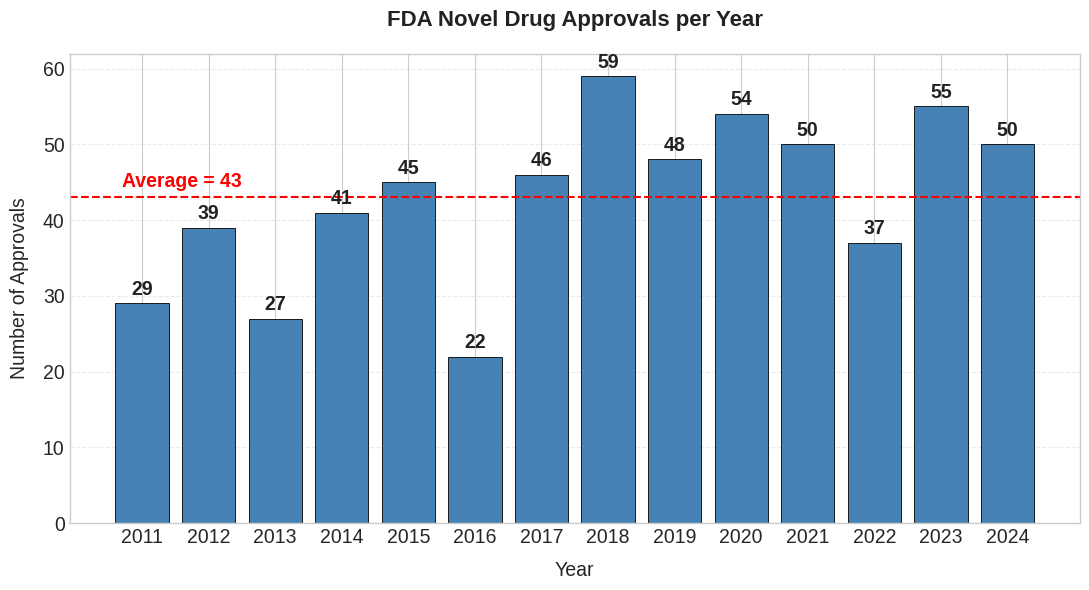

In [102]:
import matplotlib.pyplot as plt
import pandas as pd

# assuming your final dataframe is named all_years_df

# --- Prepare data ---
approvals_per_year = (
    all_years_df.groupby("year")
    .size()
    .reset_index(name="num_approvals")
    .sort_values("year")
)

avg_approvals = approvals_per_year["num_approvals"].mean()

# --- Plot ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

# Bars — uniform professional blue
bars = ax.bar(
    approvals_per_year["year"],
    approvals_per_year["num_approvals"],
    color="#4682B4",   # steel blue
    edgecolor="black",
    linewidth=0.6
)

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.6,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
        color="#222222"
    )

# Average line + label
ax.axhline(avg_approvals, color="red", linestyle="--", linewidth=1.5)
ax.text(
    approvals_per_year["year"].min() - 0.3,
    avg_approvals + 0.8,
    f"Average = {avg_approvals:.0f}",
    color="red",
    fontsize=14,
    fontweight="bold",
    va="bottom"
)

# Titles and labels
ax.set_title(
    "FDA Novel Drug Approvals per Year",
    fontsize=16,
    fontweight="bold",
    color="#222222",
    pad=20
)
ax.set_xlabel("Year", fontsize=14, labelpad=10)
ax.set_ylabel("Number of Approvals", fontsize=14, labelpad=10)

# Gridlines and ticks
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xticks(approvals_per_year["year"])
ax.set_xticklabels(approvals_per_year["year"])
ax.tick_params(axis="both", labelsize=14)

plt.tight_layout()
plt.show()
